# Treinamento de uma rede neural para previsão de vendas de casas

In [42]:
import pandas as pd
df = pd.read_csv('/content/casas_california.csv')
df

,longitude,latitude,idade_mediana_imoveis,total_comodos,total_quartos,populacao,domicilios,renda_mediana,valor_mediano_imoveis,proximidade_oceano
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   longitude              20640 non-null  float64
 1   latitude               20640 non-null  float64
 2   idade_mediana_imoveis  20640 non-null  float64
 3   total_comodos          20640 non-null  float64
 4   total_quartos          20433 non-null  float64
 5   populacao              20640 non-null  float64
 6   domicilios             20640 non-null  float64
 7   renda_mediana          20640 non-null  float64
 8   valor_mediano_imoveis  20640 non-null  float64
 9   proximidade_oceano     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [44]:
#Plote de um mapa ultilizando coordenadas

import plotly.express as px

fig = px.scatter_mapbox(df,
                        lat='latitude',
                        lon='longitude',
                        color='valor_mediano_imoveis',
                        hover_data=['renda_mediana', 'populacao'],
                        zoom = 5)
fig.update_layout(mapbox_style='open-street-map')
fig

In [45]:
df.columns

Index(['longitude', 'latitude', 'idade_mediana_imoveis', 'total_comodos',
       'total_quartos', 'populacao', 'domicilios', 'renda_mediana',
       'valor_mediano_imoveis', 'proximidade_oceano'],
      dtype='object')

In [46]:
#Preparação dos dados de entrada e saída
#Vamos excluir a coluna total_quartos, pois o foco não é tratamento de dados
#Vamos excluir a coluna com tipo 'object', pois teria que transformar em Numero

x = df[['longitude', 'latitude', 'idade_mediana_imoveis', 'total_comodos',
       'populacao', 'domicilios', 'renda_mediana']]

y = df['valor_mediano_imoveis']

In [47]:
# Normalização de dados
#Após testar, vimos o loss muito alto devido as colunas x serem muito diferentes uma da outra

from sklearn.preprocessing import StandardScaler


# Normalização dos dados de entrada
scaler_x = StandardScaler()
scaler_y = StandardScaler()


x_scaler = scaler_x.fit_transform(x)
x_scaler = pd.DataFrame(x_scaler, columns=x.columns)

# Normalização dos dados de saida
y_scaler = scaler_y.fit_transform(y.values.reshape(-1, 1))

In [48]:
#Preparação dos dados de treino e teste
from sklearn.model_selection import train_test_split

                                                    #Trocando pelo dado normalizado
xtreino, xteste, ytreino, yteste = train_test_split(x_scaler, y_scaler, test_size=0.8, random_state=42)



In [49]:
xtreino

,longitude,latitude,idade_mediana_imoveis,total_comodos,populacao,domicilios,renda_mediana
9221,-0.344548,0.701408,0.346478,-0.640258,-0.686553,-0.712857,-0.970047
10234,0.828409,-0.829562,-0.209729,-0.155743,-0.009252,0.071825,-0.735598
4763,0.603801,-0.745288,1.538349,-0.397313,-0.381900,-0.247279,-0.815502
9062,0.708618,-0.440967,0.267020,-0.612297,-0.630038,-0.655313,-0.326708
1874,-0.199800,1.544144,-0.368645,-0.815820,-0.916147,-1.024114,-0.363238
...,...,...,...,...,...,...,...
11284,0.803453,-0.867017,0.505394,-0.598545,-0.677723,-0.739013,1.315592
11964,1.067992,-0.754652,0.346478,0.205466,0.289220,-0.132192,-0.431983
5390,0.593818,-0.749970,0.584852,-0.245128,0.291870,0.071825,-0.492832
860,-1.193070,0.912092,-1.083767,0.430534,0.310414,0.155525,0.973025


In [58]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(hidden_layer_sizes=(269, 269), max_iter=300, n_iter_no_change=300, random_state=42, verbose=True)
mlp.fit(xtreino, ytreino)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



Iteration 1, loss = 0.27923586
Iteration 2, loss = 0.19341715
Iteration 3, loss = 0.17023902
Iteration 4, loss = 0.15907225
Iteration 5, loss = 0.15444520
Iteration 6, loss = 0.14824965
Iteration 7, loss = 0.14262522
Iteration 8, loss = 0.14169480
Iteration 9, loss = 0.13764973
Iteration 10, loss = 0.13493314
Iteration 11, loss = 0.13325296
Iteration 12, loss = 0.13307830
Iteration 13, loss = 0.13111708
Iteration 14, loss = 0.12896613
Iteration 15, loss = 0.12734070
Iteration 16, loss = 0.12621798
Iteration 17, loss = 0.12130207
Iteration 18, loss = 0.12251086
Iteration 19, loss = 0.12088511
Iteration 20, loss = 0.11960759
Iteration 21, loss = 0.11758326
Iteration 22, loss = 0.11552613
Iteration 23, loss = 0.11421063
Iteration 24, loss = 0.11419663
Iteration 25, loss = 0.11183915
Iteration 26, loss = 0.11283712
Iteration 27, loss = 0.11009914
Iteration 28, loss = 0.10881654
Iteration 29, loss = 0.10987401
Iteration 30, loss = 0.10910046
Iteration 31, loss = 0.10804573
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.



MLPRegressor(hidden_layer_sizes=(269, 269), max_iter=300, n_iter_no_change=300,
             random_state=42, verbose=True)

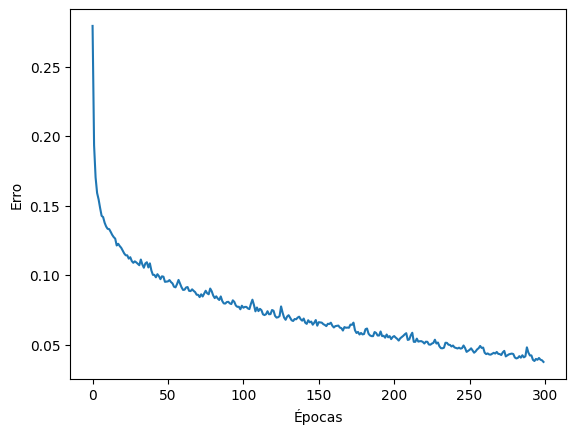

In [59]:
#Plotando a curva de aprendizagem

from matplotlib import pyplot as plt

plt.plot(mlp.loss_curve_)
plt.xlabel('Épocas')
plt.ylabel('Erro')
plt.show()

In [60]:
#Metedos para medir a performance
#R2 -> Coeficiente de Determinação (Quanto mais proximo de 1 melhor)
#MAPA -> Erro Percentual Médio Absoluto (Quanto menor melhor)
#Outros tipos MSE

from sklearn.metrics import mean_absolute_percentage_error, r2_score
                            #MAPA                           #R2
# Previsão para os dados de treino
ypred_treino_scaled = mlp.predict(xtreino)
ypred_treino = scaler_y.inverse_transform(ypred_treino_scaled.reshape(-1, 1))
ytreino_original = scaler_y.inverse_transform(ytreino)


# Previsão para os dados de teste
ypred_teste_scaled = mlp.predict(xteste)
ypred_teste = scaler_y.inverse_transform(ypred_teste_scaled.reshape(-1, 1))
yteste_original = scaler_y.inverse_transform(yteste)


# Resultados para treino
print("Resultados - Treino")
print("MAPE: {:.2f}%".format(mean_absolute_percentage_error(ytreino_original, ypred_treino) * 100))
print("R2: {:.2f}".format(r2_score(ytreino_original, ypred_treino)))


# Resultados para teste
print("\nResultados - Teste")
print("MAPE: {:.2f}%".format(mean_absolute_percentage_error(yteste_original, ypred_teste) * 100))
print("R2: {:.2f}".format(r2_score(yteste_original, ypred_teste)))

Resultados - Treino
MAPE: 11.92%
R2: 0.93

Resultados - Teste
MAPE: 21.53%
R2: 0.74
